In [1]:
import pandas as pd
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [2]:
def summarize_hyperparam(env, mu_type, alg_names):
    def summ_ep(df):
        delta = df.delta.abs().mean()
        delta_obs = df.delta_obs.abs().mean()
        rew = df.sort_values("t")["resource"].values[-1]
        accept_g0 = df[df.group_id == 0].action.mean()
        accept_g1 = df[df.group_id == 1].action.mean()
        return pd.Series(
            {
                "delta": delta,
                "delta_obs": delta_obs,
                "reward": rew,
                "accept_g0": accept_g0,
                "accept_g1": accept_g1,
            }
        )

    files = [
        f"experiments/{env}/{mu_type}/{alg}/eval/eval_data.csv" for alg in alg_names
    ]
    results = []
    for file in files:
        try:
            alg = file.split("/")[-3]
            df = pd.read_csv(file)
            df = df.groupby("ep").apply(summ_ep).aggregate(["mean", "std"])
            alg_simplified = alg.replace("sellf_hard", "sellf").split("_")[0]
            results.append(
                {
                    "alg": alg,
                    "alg_simplified": alg_simplified,
                    "delta": df["delta"]["mean"],
                    "delta_std": df["delta"]["std"],
                    "delta_obs": df["delta_obs"]["mean"],
                    "delta_obs_std": df["delta_obs"]["std"],
                    "reward": df["reward"]["mean"],
                    "reward_std": df["reward"]["std"],
                    "accept_g0": df["accept_g0"]["mean"],
                    "accept_g1": df["accept_g1"]["mean"],
                }
            )
        except:
            continue
    results = pd.DataFrame(results)

    results["minus_delta"] = 1 - results["delta"]

    delta_mean = results["minus_delta"].mean()
    delta_std = results["minus_delta"].std()

    reward_mean = results["reward"].mean()
    reward_std = results["reward"].std()

    results["score"] = (results["minus_delta"] - delta_mean) / (delta_std) + (
        results["reward"] - reward_mean
    ) / (reward_std)
    return results

In [3]:
def base_legend_func(alg_name):
    if "sellf" in alg_name:
        return "SELLF"
    if "pocar_full" in alg_name:
        return "POCAR (Oracle)"
    if "pocar" in alg_name:
        return "POCAR"
    if "ppo" in alg_name:
        return "PPO"
    return alg_name

def base_color_func(alg_name):
    if "sellf" in alg_name:
        return "#e78ac3"
    if "full" in alg_name:
        return "#fc8d62"
    if "ppo" in alg_name:
        return "#8da0cb"
    if "pocar" in alg_name:
        return "#66c2a5"

# FICO

## Ablation

In [ ]:
beta_1 = 5
selected_algs = [
    f"sellf(beta_1:{beta_1} beta_2:0)",
    f"sellf(beta_1:{beta_1} beta_2:0.05)",
    f"sellf(beta_1:{beta_1} beta_2:0.1)",
]

mu_type = "accuracy"

colors = ["#fbb4b9", "#f768a1", "#7a0177"]


def legend_func(alg_name):
    alg_name = alg_name.split(" ")[1]
    alg_name = alg_name.replace("beta_2:", "$\\beta_2=$").replace(")", "")
    return alg_name


def color_func(alg_name):
    idx = selected_algs.index(alg_name)
    return colors[idx]


# first, get average delta of each algorithm
algs_deltas = {}
df_list = [
    pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/eval/eval_data.csv")
    for alg in selected_algs
]
for i in range(len(df_list)):
    df_list[i]["delta"] = df_list[i]["delta"].abs()
    df_list[i] = (df_list[i].groupby("t").agg({"delta": "mean"})).agg(["mean", "std"])
    algs_deltas[selected_algs[i]] = {
        "mean": df_list[i]["delta"]["mean"],
        "std": df_list[i]["delta"]["std"],
    }


df_list = [
    pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/models/progress.csv")
    for alg in selected_algs
]

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))


window_size = 30
for i in range(len(df_list)):
    # make color be sequential
    reward = df_list[i]["reward"]
    reward = reward.rolling(window=window_size).mean()
    axs[0].plot(reward, color=colors[i])

    difference = (df_list[i]["delta"].abs() - df_list[i]["delta_obs"].abs()).abs()
    difference = difference.rolling(window=window_size).mean()
    axs[1].plot(difference, color=colors[i])


# bar plot of the average delta of each algorithm
axs[2].bar(
    [legend_func(alg) for alg in selected_algs],
    [algs_deltas[alg]["mean"] for alg in selected_algs],
    yerr=[algs_deltas[alg]["std"] for alg in selected_algs],
    color=colors,
)
axs[2].set_xticklabels(
    [legend_func(alg) for alg in selected_algs],
    rotation=45,
)

# axs[1].set_ylim(-0.01, 0.01)
axs[1].axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)
for i in range(2):
    axs[i].set_xlabel("Learning iteration")
axs[0].set_ylabel("Average Reward")
axs[0].set_title("Reward")
axs[1].set_title("Difference between\ntrue and observed disparity")
axs[1].set_ylabel("$|\Delta| - |\\tilde \Delta |$")
axs[2].set_title("Disparity of learned policy")
axs[2].set_ylabel("Average Disparity ($\Delta_t$)")

# add legend to the first plot
axs[0].legend(
    [legend_func(alg) for alg in selected_algs],
    loc="center left",
    bbox_to_anchor=(-0.9, 0.6),
)
plt.tight_layout()
plt.savefig("figures/ablation.pdf", bbox_inches="tight")

FileNotFoundError: [Errno 2] No such file or directory: 'experiments/fico_equal/accuracy/sellf(beta_1:5 beta_2:0)/eval/eval_data.csv'

## Decomposition

In [4]:
env_name = "fico_equal"
mu_type = "accuracy"
train_files = glob(f"experiments/ablation/**/{env_name}/{mu_type}/**/models/*.csv")
eval_files = glob(f"experiments/ablation/**/{env_name}/{mu_type}/**/eval/*.csv")
alg_dict = dict([(f.split("/")[-3], []) for f in train_files])
alg_dict_eval = dict([(f.split("/")[-3], []) for f in eval_files])
for f in train_files:
    alg_name = f.split("/")[-3]
    alg_dict[alg_name].append(f)
for f in eval_files:
    alg_name = f.split("/")[-3]
    alg_dict_eval[alg_name].append(f)

In [6]:
alg_dfs = {}

for alg_name, file_list in alg_dict.items():
    df_list = []
    for f in file_list:
        df = pd.read_csv(f)
        df["t"] = np.arange(len(df))
        df_list.append(df)
    df = pd.concat(df_list)
    df["delta_diff"] = (df["delta"] - df["delta_obs"])
    df["term_g0"] =(1 - df["accept_g0"]) * df["renyi_div_g0"]
    df["term_g1"] =(1 - df["accept_g1"]) * df["renyi_div_g1"]
    df["term"] = df["term_g0"] + df["term_g1"]

    # apply moving average with window size 10 for every numeric column
    for col in ["reward", "delta", "delta_obs", "delta_diff"]:
        df[col] = df[col].rolling(window=5).mean()

    df = df.groupby("t").agg({
        "reward": ["mean", "std"],
        "delta": ["mean", "std"],
        "delta_obs": ["mean", "std"],
        "delta_diff": ["mean", "std"],
        "term": ["mean", "std"],
    })
    alg_dfs[alg_name] = df

In [7]:
alg_dfs_eval = {}
for alg_name, file_list in alg_dict_eval.items():
    df_list = []
    for f in file_list:
        df = pd.read_csv(f)
        df["t"] = np.arange(len(df))
        df_list.append(df)
    df = pd.concat(df_list)
    df["delta"] = df["delta"].abs()
    df = df.groupby("t").agg({"delta" : "mean"})
    alg_dfs_eval[alg_name] = {
        "mean" : df["delta"].mean(),
        "std" : df["delta"].std()
    }

In [8]:
sorted_algs = sorted(alg_dfs, key = lambda x : float(x.split(":")[2].replace(")", "")))

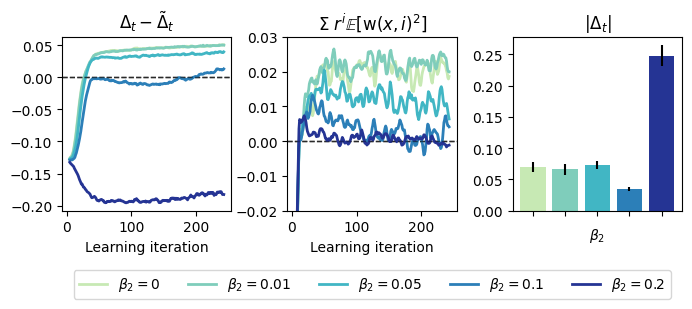

In [166]:
colors = ['#c7e9b4','#7fcdbb','#41b6c4','#2c7fb8','#253494']

def color_func(alg_name):
    idx = sorted_algs.index(alg_name)
    return colors[idx]

def legend_func(alg_name):
    return alg_name.split(" ")[-1].replace(")", "").replace("beta_2:", "$\\beta_2=$") 


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 3))

for alg_name in sorted_algs:
    df = alg_dfs[alg_name]
    axs[0].plot(
        df["reward"]["mean"],
        label=legend_func(alg_name),
        color=color_func(alg_name),
        lw = 2,
    )

    #axs[0].fill_between(
    #    df.index,
    #    df["reward"]["mean"] - df["reward"]["std"],
    #    df["reward"]["mean"] + df["reward"]["std"],
    #    alpha=0.3,
    #)

    axs[0].axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)


    axs[1].plot(
        df["delta_diff"]["mean"],
        label=legend_func(alg_name),
        color=color_func(alg_name), 
        lw = 2,
    )

    #axs[1].fill_between(
    #    df.index,
    #    df["delta_diff"]["mean"] - df["delta_diff"]["std"],
    #    df["delta_diff"]["mean"] + df["delta_diff"]["std"],
    #    alpha=0.3,
    #)

    axs[1].axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)


    df = alg_dfs_eval[alg_name]
    axs[2].bar(
        alg_name,
        df["mean"],
        yerr=df["std"],
        color=color_func(alg_name),
    )
    axs[2].set_xticks(range(len(sorted_algs)))
    axs[2].set_xticklabels(
        ["" for s in sorted_algs],
        #[s.split(" ")[-1].replace(")", "").replace("beta_2:", "$\\beta_2=$") for s in sorted_algs],
        rotation=45,
    )
    #plt.show()

axs[1].set_ylim(-0.02, 0.03)
axs[0].set_title("$\Delta_t - \\tilde \Delta_t $")
axs[1].set_title("Σ $r^i \mathbb{E}[\mathrm{w}(x, i)^2]$")
axs[2].set_title("$|\Delta_t|$")

fig.subplots_adjust(bottom=0.3, wspace=0.33)

axs[0].set_xlabel("Learning iteration")
axs[1].set_xlabel("Learning iteration")
axs[2].set_xlabel("$\\beta_2$")
axs[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=5,
)

plt.savefig("figures/ablation_beta2.pdf", bbox_inches="tight")



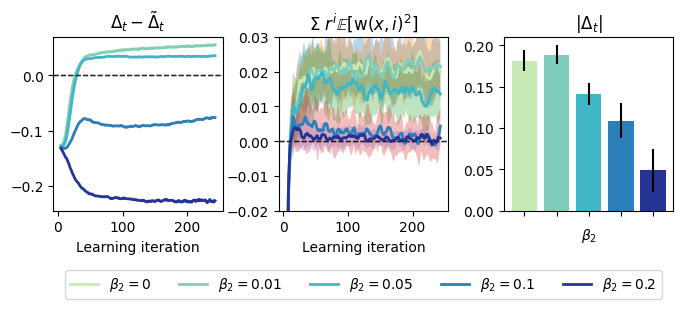

In [11]:
colors = ['#c7e9b4','#7fcdbb','#41b6c4','#2c7fb8','#253494']

def color_func(alg_name):
    idx = sorted_algs.index(alg_name)
    return colors[idx]

def legend_func(alg_name):
    return alg_name.split(" ")[-1].replace(")", "").replace("beta_2:", "$\\beta_2=$") 


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 3))

for alg_name in sorted_algs:
    df = alg_dfs[alg_name]
    axs[0].plot(
        df["reward"]["mean"],
        label=legend_func(alg_name),
        color=color_func(alg_name),
        lw = 2,
    )

    #axs[0].fill_between(
    #    df.index,
    #    df["reward"]["mean"] - df["reward"]["std"],
    #    df["reward"]["mean"] + df["reward"]["std"],
    #    alpha=0.3,
    #)

    axs[0].axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)


    axs[1].plot(
        df["delta_diff"]["mean"],
        label=legend_func(alg_name),
        color=color_func(alg_name), 
        lw = 2,
    )

    axs[1].fill_between(
        df.index,
        df["delta_diff"]["mean"] - df["delta_diff"]["std"],
        df["delta_diff"]["mean"] + df["delta_diff"]["std"],
        alpha=0.3,
    )

    axs[1].axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)


    df = alg_dfs_eval[alg_name]
    axs[2].bar(
        alg_name,
        df["mean"],
        yerr=df["std"],
        color=color_func(alg_name),
    )
    axs[2].set_xticks(range(len(sorted_algs)))
    axs[2].set_xticklabels(
        ["" for s in sorted_algs],
        #[s.split(" ")[-1].replace(")", "").replace("beta_2:", "$\\beta_2=$") for s in sorted_algs],
        rotation=45,
    )
    #plt.show()

axs[1].set_ylim(-0.02, 0.03)
axs[0].set_title("$\Delta_t - \\tilde \Delta_t $")
axs[1].set_title("Σ $r^i \mathbb{E}[\mathrm{w}(x, i)^2]$")
axs[2].set_title("$|\Delta_t|$")

fig.subplots_adjust(bottom=0.3, wspace=0.33)

axs[0].set_xlabel("Learning iteration")
axs[1].set_xlabel("Learning iteration")
axs[2].set_xlabel("$\\beta_2$")
axs[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=5,
)

plt.savefig("figures/ablation_beta2.pdf", bbox_inches="tight")



## Comparative Evaluation

### Equality of opportunity

In [68]:
env_name = "fico_equal"
mu_type = "tpr"
alg_names = ["ppo()"]
for beta_1 in [1, 2, 5, 10]:
    for beta_2 in [0, 0.05, 0.1]:
        alg_names.append(f"sellf(beta_1:{beta_1} beta_2:{beta_2})")
    for beta_2 in [1, 2, 5, 10]:
        alg_names.append(f"pocar(beta_1:{beta_1} beta_2:{beta_2})")
        alg_names.append(f"pocar_full(beta_1:{beta_1} beta_2:{beta_2})")
results = summarize_hyperparam(env_name, mu_type, alg_names)
results.sort_values("score", ascending=False).groupby("alg_simplified").first()

,alg,delta,delta_std,delta_obs,delta_obs_std,reward,reward_std,accept_g0,accept_g1,minus_delta,score
alg_simplified,,,,,,,,,,,
pocar,pocar_full(beta_1:10 beta_2:2),0.017448,0.009327,0.017448,0.009327,1229.70,15.989232,0.163394,0.320700,0.982552,0.829297
pocar(beta,pocar(beta_1:2 beta_2:5),0.377165,0.005951,0.000000,0.000000,1613.36,16.760748,0.168510,0.645589,0.622835,-0.396719
ppo(),ppo(),0.391542,0.005529,0.391542,0.005529,1611.68,17.242892,0.162750,0.644618,0.608458,-0.498532
sellf(beta,sellf(beta_1:2 beta_2:0.05),0.122210,0.009668,0.126480,0.013578,1550.62,18.666774,0.281132,0.663726,0.877790,1.121590


In [69]:
selected_algs = (
    results.sort_values("score", ascending=False)
    .groupby("alg_simplified")
    .first()["alg"]
    .tolist()
)

# place sellf first
sellf_alg = [alg for alg in selected_algs if "sellf" in alg][0]
selected_algs.remove(sellf_alg)
selected_algs = [sellf_alg] + selected_algs

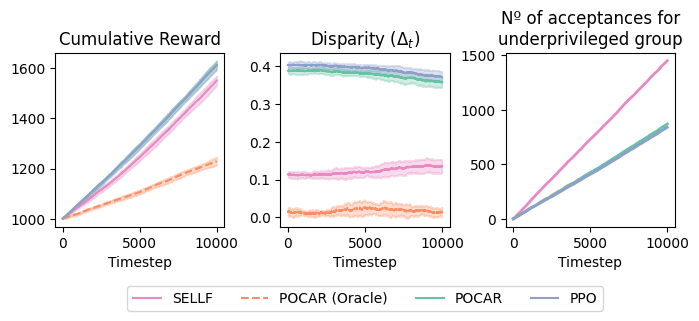

In [86]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 3))

df_list = [
    pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/eval/eval_data.csv")
    for alg in selected_algs
]

for i in range(len(df_list)):
    df_list[i]["accept_g0"] = df_list[i]["action"] * (df_list[i]["group_id"] == 0)
    df_list[i]["accept_g1"] = df_list[i]["action"] * (df_list[i]["group_id"] == 1)

    # for each ep, compute cumulative sum of accept_g0 and accept_g1
    df_list[i]["n_accept_g0"] = df_list[i].groupby("ep")["accept_g0"].cumsum()
    df_list[i]["n_accept_g1"] = df_list[i].groupby("ep")["accept_g1"].cumsum()

    df_list[i]["delta"] = df_list[i]["delta"].abs()

    df_list[i] = (
        df_list[i]
        .groupby("t")
        .agg(
            {
                "resource": ["mean", "std"],
                "delta": ["mean", "std"],
                "n_accept_g0": ["mean", "std"],
                "n_accept_g1": ["mean", "std"],
            }
        )
    )

for alg, df in zip(selected_algs, df_list):
    axs[0].plot(
        df.index,
        df["resource"]["mean"],
        label=base_legend_func(alg),
        color=base_color_func(alg),
        linestyle="--" if "full" in alg else "-",
    )
    axs[0].fill_between(
        df.index,
        df["resource"]["mean"] - df["resource"]["std"],
        df["resource"]["mean"] + df["resource"]["std"],
        alpha=0.3,
        color=base_color_func(alg),
    )

    axs[1].plot(
        df.index,
        df["delta"]["mean"],
        label=base_legend_func(alg),
        color=base_color_func(alg),
        linestyle="--" if "full" in alg else "-",
    )
    axs[1].fill_between(
        df.index,
        df["delta"]["mean"] - df["delta"]["std"],
        df["delta"]["mean"] + df["delta"]["std"],
        alpha=0.3,
        color=base_color_func(alg),
    )

    diff_accept = df["n_accept_g0"]["mean"]
    axs[2].plot(
        df.index,
        diff_accept,
        label=base_legend_func(alg),
        color=base_color_func(alg),
        linestyle="--" if "full" in alg else "-",
        lw=2,
    )

for i in range(3):
    axs[i].set_xlabel("Timestep")

axs[0].set_title("Cumulative Reward")
axs[1].set_title("Disparity ($\Delta_t$)")
axs[2].set_title("Nº of acceptances for\nunderprivileged group")

# place legend outside bellow all plots
fig.subplots_adjust(bottom=0.3, wspace=0.33)

axs[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=len(selected_algs),
)

plt.savefig("figures/fico_tpr.pdf", bbox_inches="tight")
plt.show()

### Accuracy

In [4]:
env_name = "fico_equal"
mu_type = "accuracy"
alg_names = ["ppo()"]
for beta_1 in [1, 2, 5, 10]:
    for beta_2 in [0, 0.05, 0.1]:
        alg_names.append(f"sellf(beta_1:{beta_1} beta_2:{beta_2})")
    for beta_2 in [1, 2, 5, 10]:
        alg_names.append(f"pocar(beta_1:{beta_1} beta_2:{beta_2})")
        alg_names.append(f"pocar_full(beta_1:{beta_1} beta_2:{beta_2})")
results = summarize_hyperparam(env_name, mu_type, alg_names)
results.sort_values("score", ascending=False).groupby("alg_simplified").first()

,alg,delta,delta_std,delta_obs,delta_obs_std,reward,reward_std,accept_g0,accept_g1,minus_delta,score
alg_simplified,,,,,,,,,,,
pocar,pocar_full(beta_1:5 beta_2:5),0.065155,0.009576,0.065155,0.009576,1408.20,17.001438,0.011177,0.557676,0.934845,0.548768
pocar(beta,pocar(beta_1:1 beta_2:1),0.069418,0.005407,0.042548,0.011650,1590.78,15.113923,0.131084,0.648790,0.930582,1.284132
ppo(),ppo(),0.043601,0.004714,0.043601,0.004714,1611.68,17.242892,0.162750,0.644618,0.956399,2.076815
sellf(beta,sellf(beta_1:1 beta_2:0.05),0.048336,0.005425,0.033261,0.007216,1613.48,16.270819,0.193420,0.695330,0.951664,1.957672


In [9]:
selected_algs = (
    results.sort_values("score", ascending=False)
    .groupby("alg_simplified")
    .first()["alg"]
    .tolist()
)

# place sellf first
sellf_alg = [alg for alg in selected_algs if "sellf" in alg][0]
selected_algs.remove(sellf_alg)
selected_algs = [sellf_alg] + selected_algs

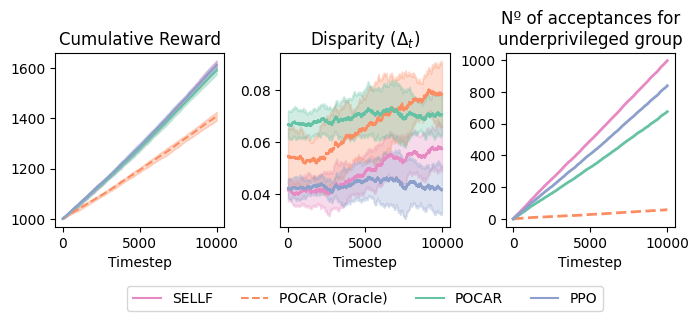

In [10]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 3))

df_list = [
    pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/eval/eval_data.csv")
    for alg in selected_algs
]

for i in range(len(df_list)):
    df_list[i]["accept_g0"] = df_list[i]["action"] * (df_list[i]["group_id"] == 0)
    df_list[i]["accept_g1"] = df_list[i]["action"] * (df_list[i]["group_id"] == 1)

    # for each ep, compute cumulative sum of accept_g0 and accept_g1
    df_list[i]["n_accept_g0"] = df_list[i].groupby("ep")["accept_g0"].cumsum()
    df_list[i]["n_accept_g1"] = df_list[i].groupby("ep")["accept_g1"].cumsum()

    df_list[i]["delta"] = df_list[i]["delta"].abs()

    df_list[i] = (
        df_list[i]
        .groupby("t")
        .agg(
            {
                "resource": ["mean", "std"],
                "delta": ["mean", "std"],
                "n_accept_g0": ["mean", "std"],
                "n_accept_g1": ["mean", "std"],
            }
        )
    )

for alg, df in zip(selected_algs, df_list):
    axs[0].plot(
        df.index,
        df["resource"]["mean"],
        label=base_legend_func(alg),
        color=base_color_func(alg),
        linestyle="--" if "full" in alg else "-",
    )
    axs[0].fill_between(
        df.index,
        df["resource"]["mean"] - df["resource"]["std"],
        df["resource"]["mean"] + df["resource"]["std"],
        alpha=0.3,
        color=base_color_func(alg),
    )

    axs[1].plot(
        df.index,
        df["delta"]["mean"],
        label=base_legend_func(alg),
        color=base_color_func(alg),
        linestyle="--" if "full" in alg else "-",
    )
    axs[1].fill_between(
        df.index,
        df["delta"]["mean"] - df["delta"]["std"],
        df["delta"]["mean"] + df["delta"]["std"],
        alpha=0.3,
        color=base_color_func(alg),
    )

    diff_accept = df["n_accept_g0"]["mean"]
    axs[2].plot(
        df.index,
        diff_accept,
        label=base_legend_func(alg),
        color=base_color_func(alg),
        linestyle="--" if "full" in alg else "-",
        lw=2,
    )

for i in range(3):
    axs[i].set_xlabel("Timestep")

axs[0].set_title("Cumulative Reward")
axs[1].set_title("Disparity ($\Delta_t$)")
axs[2].set_title("Nº of acceptances for\nunderprivileged group")

# place legend outside bellow all plots
fig.subplots_adjust(bottom=0.3, wspace=0.33)

axs[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=len(selected_algs),
)

plt.show()

### Qualification parity

In [15]:
np.random.randint(0, 10_000, 25)

array([8525, 2892, 5666, 3309, 6898, 2052, 8530, 8624, 7070, 8094, 1961,
       2866, 9674, 9684, 9928, 9664, 8616, 2029, 9816, 8070, 3413, 2989,
       2807, 4163, 7576])

In [4]:
sorted([8525, 2892, 5666, 3309, 6898, 2052, 8530, 8624, 7070, 8094, 1961,
       2866, 9674, 9684, 9928, 9664, 8616, 2029, 9816, 8070, 3413, 2989,
       2807, 4163, 7576])

[1961,
 2029,
 2052,
 2807,
 2866,
 2892,
 2989,
 3309,
 3413,
 4163,
 5666,
 6898,
 7070,
 7576,
 8070,
 8094,
 8525,
 8530,
 8616,
 8624,
 9664,
 9674,
 9684,
 9816,
 9928]

In [13]:
env_name = "fico_no_decay"
mu_type = "qualification"
alg_names = ["ppo()"]
for beta_1 in [1, 2, 5, 10]:
    for beta_2 in [0, 0.05, 0.1]:
        alg_names.append(f"sellf(beta_1:{beta_1} beta_2:{beta_2})")
    for beta_2 in [1, 2, 5, 10]:
        alg_names.append(f"pocar(beta_1:{beta_1} beta_2:{beta_2})")
        alg_names.append(f"pocar_full(beta_1:{beta_1} beta_2:{beta_2})")
for decision_type in ["accept_g0", "accept_g1", "min_max", "random", "all_deny", "all_aprove"]:
    alg_names.append(f"simple_agent(decision_type:{decision_type})")
results = summarize_hyperparam(env_name, mu_type, alg_names)
results.sort_values("delta", ascending=True).groupby("alg_simplified").first()

,alg,delta,delta_std,delta_obs,delta_obs_std,reward,reward_std,accept_g0,accept_g1,minus_delta,score
alg_simplified,,,,,,,,,,,
sellf(beta,sellf(beta_1:10 beta_2:0.1),0.369482,0.004522,0.368957,0.005220,0.0,0.0,0.889216,0.908656,0.630518,0.656178
simple,simple_agent(decision_type:min_max),0.406387,0.002914,0.406387,0.002914,0.0,0.0,1.000000,0.000000,0.593613,-0.874834


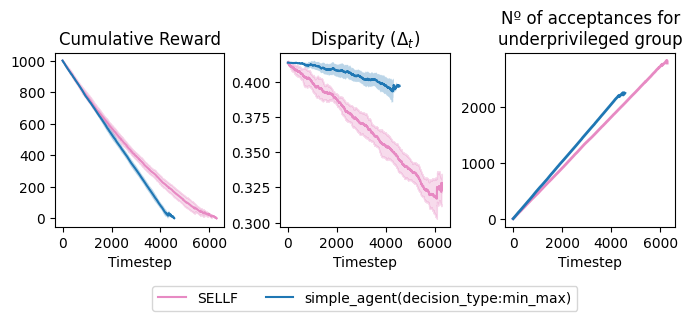

In [14]:
selected_algs = (
    results.sort_values("delta", ascending=True)
    .groupby("alg_simplified")
    .first()["alg"]
    .tolist()
)


# place sellf first
try:
    sellf_alg = [alg for alg in selected_algs if "sellf" in alg][0]
    selected_algs.remove(sellf_alg)
    selected_algs = [sellf_alg] + selected_algs
except:
    pass

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 3))

df_list = [
    pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/eval/eval_data.csv")
    for alg in selected_algs
]

for i in range(len(df_list)):
    df_list[i]["accept_g0"] = df_list[i]["action"] * (df_list[i]["group_id"] == 0)
    df_list[i]["accept_g1"] = df_list[i]["action"] * (df_list[i]["group_id"] == 1)

    # for each ep, compute cumulative sum of accept_g0 and accept_g1
    df_list[i]["n_accept_g0"] = df_list[i].groupby("ep")["accept_g0"].cumsum()
    df_list[i]["n_accept_g1"] = df_list[i].groupby("ep")["accept_g1"].cumsum()

    df_list[i]["delta"] = df_list[i]["delta"].abs()

    df_list[i] = (
        df_list[i]
        .groupby("t")
        .agg(
            {
                "resource": ["mean", "std"],
                "delta": ["mean", "std"],
                "n_accept_g0": ["mean", "std"],
                "n_accept_g1": ["mean", "std"],
            }
        )
    )

for alg, df in zip(selected_algs, df_list):
    axs[0].plot(
        df.index,
        df["resource"]["mean"],
        label=base_legend_func(alg),
        color=base_color_func(alg),
        linestyle="--" if "full" in alg else "-",
    )
    axs[0].fill_between(
        df.index,
        df["resource"]["mean"] - df["resource"]["std"],
        df["resource"]["mean"] + df["resource"]["std"],
        alpha=0.3,
        color=base_color_func(alg),
    )

    axs[1].plot(
        df.index,
        df["delta"]["mean"],
        label=base_legend_func(alg),
        color=base_color_func(alg),
        linestyle="--" if "full" in alg else "-",
    )
    axs[1].fill_between(
        df.index,
        df["delta"]["mean"] - df["delta"]["std"],
        df["delta"]["mean"] + df["delta"]["std"],
        alpha=0.3,
        color=base_color_func(alg),
    )

    diff_accept = df["n_accept_g0"]["mean"]
    axs[2].plot(
        df.index,
        diff_accept,
        label=base_legend_func(alg),
        color=base_color_func(alg),
        linestyle="--" if "full" in alg else "-",
        lw=2,
    )

for i in range(3):
    axs[i].set_xlabel("Timestep")

axs[0].set_title("Cumulative Reward")
axs[1].set_title("Disparity ($\Delta_t$)")
axs[2].set_title("Nº of acceptances for\nunderprivileged group")

# place legend outside bellow all plots
fig.subplots_adjust(bottom=0.3, wspace=0.33)

axs[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=len(selected_algs),
)

plt.show()

# ENEM

## Comparative

### Equality of opportunity

In [12]:
env_name = "enem"
mu_type = "tpr"
alg_names = ["ppo()"]
for beta_1 in [1, 2, 5, 10]:
    for beta_2 in [0, 0.05, 0.1]:
        alg_names.append(f"sellf(beta_1:{beta_1} beta_2:{beta_2})")
    for beta_2 in [1, 2, 5, 10]:
        alg_names.append(f"pocar(beta_1:{beta_1} beta_2:{beta_2})")
        alg_names.append(f"pocar_full(beta_1:{beta_1} beta_2:{beta_2})")
results = summarize_hyperparam(env_name, mu_type, alg_names)
results.sort_values("score", ascending=False).groupby("alg_simplified").first()

,alg,delta,delta_std,delta_obs,delta_obs_std,reward,reward_std,accept_g0,accept_g1,minus_delta,score
alg_simplified,,,,,,,,,,,
pocar,pocar_full(beta_1:2 beta_2:5),0.048957,0.010396,0.048957,0.010396,1120.35,6.996229,0.304204,0.413775,0.951043,0.738254
pocar(beta,pocar(beta_1:2 beta_2:5),0.205838,0.012744,0.000000,0.000000,1138.55,5.609763,0.188769,0.404892,0.794162,-0.409517
ppo(),ppo(),0.207415,0.011349,0.207415,0.011349,1138.45,5.494694,0.187712,0.402123,0.792585,-0.432711
sellf(beta,sellf(beta_1:2 beta_2:0),0.017920,0.009425,0.018480,0.012794,1119.60,11.476546,0.296707,0.358559,0.982080,1.082841


### Accuracy

In [13]:
env_name = "enem"
mu_type = "accuracy"
alg_names = ["ppo()"]
for beta_1 in [1, 2, 5, 10]:
    for beta_2 in [0, 0.05, 0.1]:
        alg_names.append(f"sellf(beta_1:{beta_1} beta_2:{beta_2})")
    for beta_2 in [1, 2, 5, 10]:
        alg_names.append(f"pocar(beta_1:{beta_1} beta_2:{beta_2})")
        alg_names.append(f"pocar_full(beta_1:{beta_1} beta_2:{beta_2})")
results = summarize_hyperparam(env_name, mu_type, alg_names)
results.sort_values("score", ascending=False).groupby("alg_simplified").first()

,alg,delta,delta_std,delta_obs,delta_obs_std,reward,reward_std,accept_g0,accept_g1,minus_delta,score
alg_simplified,,,,,,,,,,,
pocar,pocar_full(beta_1:1 beta_2:2),0.073959,0.009046,0.073959,0.009046,1122.05,6.672706,0.178983,0.391201,0.926041,0.299233
pocar(beta,pocar(beta_1:10 beta_2:5),0.014445,0.008842,0.112310,0.009655,977.50,8.885069,0.475916,0.501899,0.985555,0.787338
ppo(),ppo(),0.072844,0.005025,0.072844,0.005025,1138.45,5.494694,0.187712,0.402123,0.927156,0.673003
sellf(beta,sellf(beta_1:2 beta_2:0),0.070368,0.007522,0.053407,0.016285,1140.90,10.281591,0.192850,0.426629,0.929632,0.854828


In [ ]:
selected_algs = (
    results.sort_values("score", ascending=False)
    .groupby("alg_simplified")
    .first()["alg"]
    .tolist()
)

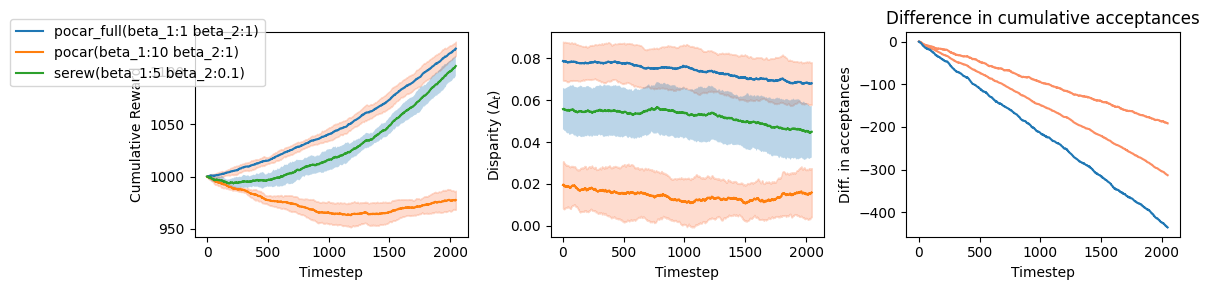

In [ ]:
df_list = [
    pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/eval/eval_data.csv")
    for alg in selected_algs
]
for i in range(len(df_list)):
    # create column with number of acceptions for each group
    df_list[i]["accept_g0"] = df_list[i]["action"] * (df_list[i]["group_id"] == 0)
    df_list[i]["accept_g1"] = df_list[i]["action"] * (df_list[i]["group_id"] == 1)

    # for each ep, compute cumulative sum of accept_g0 and accept_g1
    df_list[i]["n_accept_g0"] = df_list[i].groupby("ep")["accept_g0"].cumsum()
    df_list[i]["n_accept_g1"] = df_list[i].groupby("ep")["accept_g1"].cumsum()
    df_list[i]["delta"] = df_list[i]["delta"].abs()

    df_list[i] = (
        df_list[i]
        .groupby("t")
        .agg(
            {
                "resource": ["mean", "std"],
                "delta": ["mean", "std"],
                "n_accept_g0": ["mean", "std"],
                "n_accept_g1": ["mean", "std"],
            }
        )
    )


def legend_func(alg_name):
    return alg_name
    if "sellf" in alg_name:
        return "Sellf"
    if "ppo" in alg_name:
        return "PPO"
    if "pocar" in alg_name:
        return "POCAR"
    return alg_name


def color_func(alg_name):
    if "sellf" in alg_name:
        return "#e78ac3"
    if "ppo" in alg_name:
        return "#8da0cb"
    if "pocar" in alg_name:
        return "#fc8d62"


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))
for alg, df in zip(selected_algs, df_list):
    axs[0].plot(
        df.index,
        df["resource"]["mean"],
        label=legend_func(alg),  # , color=color_func(alg)
    )
    axs[0].fill_between(
        df.index,
        df["resource"]["mean"] - df["resource"]["std"],
        df["resource"]["mean"] + df["resource"]["std"],
        alpha=0.3,
        color=color_func(alg),
    )

    axs[1].plot(
        df.index, df["delta"]["mean"], label=legend_func(alg)  # , color=color_func(alg)
    )
    axs[1].fill_between(
        df.index,
        df["delta"]["mean"] - df["delta"]["std"],
        df["delta"]["mean"] + df["delta"]["std"],
        alpha=0.3,
        color=color_func(alg),
    )

    # calculate the difference in acceptance
    diff_accept = df["n_accept_g0"]["mean"] - df["n_accept_g1"]["mean"]
    axs[2].plot(
        df.index,
        diff_accept,
        label=legend_func(alg),
        color=color_func(alg),
    )


for i in range(3):
    axs[i].set_xlabel("Timestep")

axs[0].set_ylabel("Cumulative Reward")
axs[1].set_ylabel("Disparity ($\Delta_t$)")
axs[2].set_ylabel("Diff. in acceptances")
axs[2].set_title("Difference in cumulative acceptances")


# place legend outside the left plot
axs[0].legend(loc="center left", bbox_to_anchor=(-0.7, 0.9))
plt.tight_layout()
# plt.savefig("figures/fico_tpr.pdf", bbox_inches='tight')
plt.show()

### Qualification parity

In [180]:
env_name = "enem"
mu_type = "qualification"
alg_names = ["ppo()"]
for beta_1 in [1, 2, 5, 10]:
    for beta_2 in [0, 0.05, 0.1]:
        alg_names.append(f"sellf(beta_1:{beta_1} beta_2:{beta_2})")
    for beta_2 in [1, 2, 5, 10]:
        alg_names.append(f"pocar(beta_1:{beta_1} beta_2:{beta_2})")
        alg_names.append(f"pocar_full(beta_1:{beta_1} beta_2:{beta_2})")
results = summarize_hyperparam(env_name, mu_type, alg_names)
results.sort_values("score", ascending=False).groupby("alg_simplified").first()

,alg,delta,delta_std,delta_obs,delta_obs_std,reward,reward_std,accept_g0,accept_g1,minus_delta,score
alg_simplified,,,,,,,,,,,
pocar,pocar_full(beta_1:1 beta_2:1),0.117056,0.001797,0.117056,0.001797,1131.95,5.941614,0.224953,0.475748,0.882944,NaN
